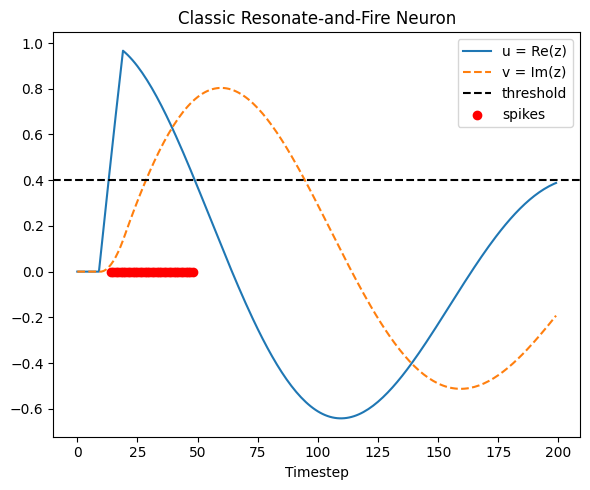

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
T = 200
delta = 0.1  # smaller timestep helps stabilize oscillation
omega = 2 * np.pi * 0.05  # ~10 Hz if 1 kHz sampling
b = -0.05  # mild damping

# Input current: short pulse
I = np.zeros(T)
I[10:20] = 1.0  # a short pulse

# Initialization
u = np.zeros(T, dtype=complex)
spikes = np.zeros(T)
threshold = 0.4

# Euler integration of u' = (b + iω)u + I
for t in range(1, T):
    u[t] = u[t-1] + delta * ((b + 1j * omega) * u[t-1] + I[t])
    if u[t].real > threshold:
        spikes[t] = 1

# Plot
plt.figure(figsize=(6, 5))
plt.plot(u.real, label='u = Re(z)')
plt.plot(u.imag, label='v = Im(z)', linestyle='--')
plt.axhline(threshold, color='k', linestyle='--', label='threshold')
spike_times = np.where(spikes == 1)[0]
plt.scatter(spike_times, np.full_like(spike_times, threshold), color='red', label='spikes')
plt.legend()
plt.xlabel("Timestep")
plt.title("Classic Resonate-and-Fire Neuron")
plt.tight_layout()
plt.show()


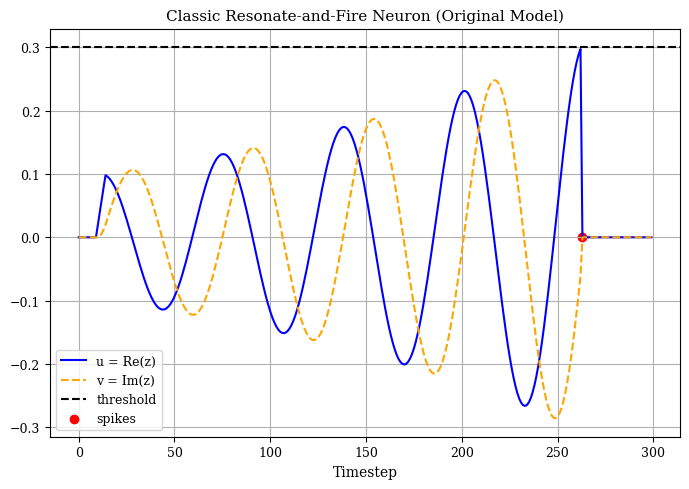

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Time parameters
T = 300
dt = 0.01
time = np.arange(T)

# Neuron parameters
omega = 10.0       # angular frequency
b = -0.05          # mild damping
theta = 0.3        # threshold

# Input: short burst of current
I = np.zeros(T)
I[10:15] = 2.0     # burst to build oscillation

# State init
z = np.zeros(T, dtype=complex)
spikes = np.zeros(T)

# Simulation
for t in range(1, T):
    z[t] = z[t-1] + dt * ((b + 1j * omega) * z[t-1] + I[t])
    if z[t].real > theta:
        spikes[t] = 1
        z[t] = 0  # hard reset as in original Izhikevich model

# Plot
plt.figure(figsize=(7, 5))
plt.plot(time, z.real, label='u = Re(z)', color='blue')
plt.plot(time, z.imag, label='v = Im(z)', color='orange', linestyle='dashed')
plt.axhline(y=theta, color='k', linestyle='--', label='threshold')
plt.scatter(np.where(spikes == 1)[0],
            np.full_like(np.where(spikes == 1)[0], theta),
            color='red', label='spikes')
plt.title("Classic Resonate-and-Fire Neuron (Original Model)")
plt.xlabel("Timestep")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Balanced Resonate and Fire

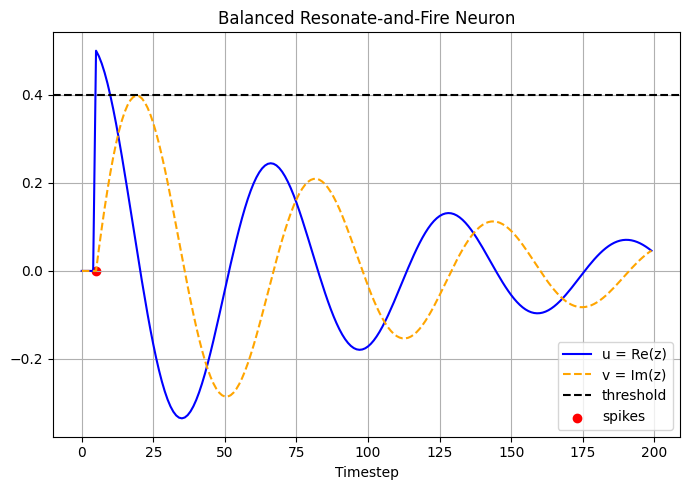

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Time parameters
T = 200
dt = 0.01
time = np.arange(T)

# Neuron parameters
omega = 10.0
bc = 1.0
theta = 0.4
gamma = 0.9

# Input: single pulse
I = np.zeros(T)
I[5] = 50.0  # increase strength

# Initialize variables
u = np.zeros(T)
v = np.zeros(T)
q = np.zeros(T)
spikes = np.zeros(T)

# Sustain oscillation boundary
p_omega = (-1 + np.sqrt(1 - (dt * omega)**2)) / dt

# Simulation loop
for t in range(1, T):
    b = p_omega - bc - q[t - 1]
    u[t] = u[t - 1] + b * u[t - 1] * dt - omega * v[t - 1] * dt + I[t] * dt
    v[t] = v[t - 1] + omega * u[t - 1] * dt + b * v[t - 1] * dt
    spikes[t] = 1 if (u[t] - theta - q[t - 1]) > 0 else 0
    q[t] = gamma * q[t - 1] + spikes[t]

# Plotting
plt.figure(figsize=(7, 5))
plt.plot(time, u, label='u = Re(z)', color='blue')
plt.plot(time, v, label='v = Im(z)', color='orange', linestyle='dashed')
plt.axhline(y=theta, color='k', linestyle='--', label='threshold')
plt.scatter(np.where(spikes == 1)[0], np.full_like(np.where(spikes == 1)[0], theta), color='red', label='spikes')
plt.title("Balanced Resonate-and-Fire Neuron")
plt.xlabel("Timestep")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
